# Task 1

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


salary_df = pd.read_csv("Data/Salary.csv", index_col=[0])
insurance_df = pd.read_csv("Data/Insurance.csv")

In [3]:
salary_df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [4]:
insurance_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Task 2

In [5]:
X_salary = salary_df[["YearsExperience"]]
y_salary = salary_df["Salary"]

model = LinearRegression()
model.fit(X_salary, y_salary)
print(model.coef_[0])
print(model.intercept_)

#For every year of experience the salary goes up by 9450
#The intercept is the base pay for 0 years of experience

9449.962321455077
24848.203966523193


# Task 3

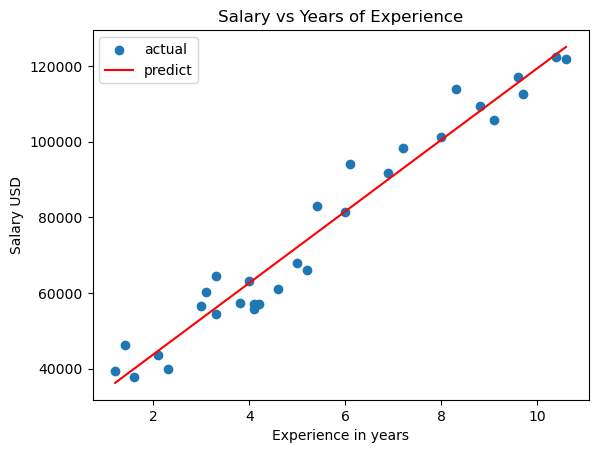

In [6]:
plt.scatter(x=salary_df["YearsExperience"], y=salary_df["Salary"], label="actual")
plt.plot(salary_df["YearsExperience"], model.predict(X_salary), color="Red", label="predict")
plt.title("Salary vs Years of Experience")
plt.ylabel("Salary USD")
plt.xlabel("Experience in years")
plt.legend()

# Task 4

In [7]:
new_data = pd.DataFrame({"YearsExperience": [5.5]})
print(model.predict(new_data))

[76822.99673453]


In [8]:
print(24848.20 + (9449.96 * 5.5))

#First you have the intercet then you add it to the coefficient multiplied by the YearsExperience

76822.98


# Task 5

In [ ]:
X_ins = insurance_df[['age','bmi','children']]
y_ins = insurance_df['charges']

model_ins = LinearRegression()
model_ins.fit(X_ins, y_ins)

for feat, coef in zip(X_ins.columns, model_ins.coef_):
    print(f'Feature: {feat}, Coefficient: {coef}')

# Age coefficient: For every year older, insurance charges go up by $240
# BMI coefficient: for every increase in BMI, insurance charges go up by $332
# Children coefficent: for every additional child, charges go up by $543

Feature: age, Coefficient: 239.99447429364608
Feature: bmi, Coefficient: 332.0833645034482
Feature: children, Coefficient: 542.8646522470191


# Task 6

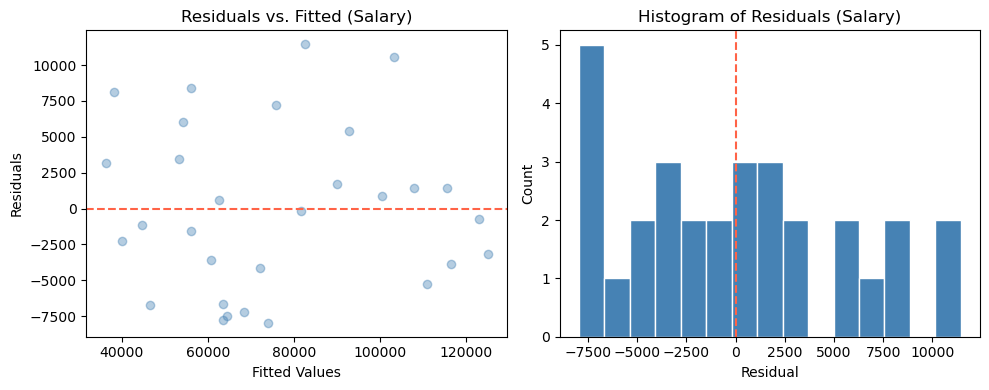

In [ ]:
salary_df['predicted'] = model.predict(X_salary)
salary_df['residual'] = salary_df['Salary'] - salary_df['predicted']

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(salary_df['predicted'], salary_df['residual'],
            color='steelblue', alpha=0.4)
plt.axhline(0, color='tomato', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted (Salary)')

plt.subplot(1, 2, 2)
plt.hist(salary_df['residual'], bins=15, color='steelblue',
         edgecolor='white')
plt.axvline(0, color='tomato', linestyle='--')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.title('Histogram of Residuals (Salary)')

plt.tight_layout()
plt.show()

# Yes the residuals look evenly spread
# No the residuals don't look bell-shaped, they appear skewed left. The model frequently predicts salary too high

# Advanced Tasks

## Task 7

Text(0.5, 1.0, 'Residuals vs. Fitted (Insurance Charges)')

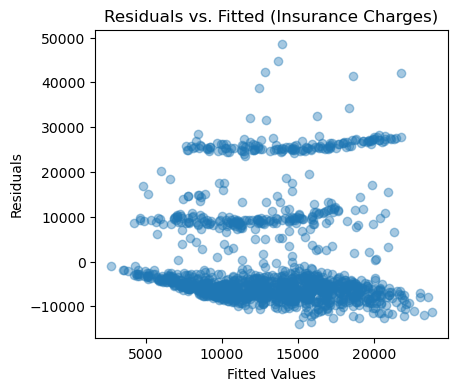

In [ ]:
insurance_df['predicted'] = model_ins.predict(X_ins)
insurance_df['residual'] = insurance_df['charges'] - insurance_df['predicted']

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(insurance_df['predicted'], insurance_df['residual'], alpha=0.4)
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted (Insurance Charges)')


plt.subplot(1,2,2)
plt.hist()